# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 05: Regressão**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br) EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                               | Local           |
|-------------------------------|---------------|------------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>10:00</font> | Teams (ao vivo) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>13:30</font> | Teams (ao vivo) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_05_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

## <font color='green'>Contextualização</font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>R. Quinlan. "Auto MPG," UCI Machine Learning Repository, 1993. https://doi.org/10.24432/C5859H.</font>

O dataset contém o domínio de análise de eficiência de veículos automotores. Tem o objetivo de permitr a predição do consumo de combustível (medido em milhas por galão) a partir das caraacterísticas técnicas dos carros. A base contém informações como número de cilindros, deslocamento do motor, potência, peso, aceleração, ano do modelo e origem do veículo.

## <font color='green'>Preparação</font>

In [1]:
!pip install pandas scikit-learn ucimlrepo

In [4]:
import pandas as pd

colunas = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin",
    "car_name"
]

# Importar o dataset Auto MPG (ID 9)
df = pd.read_csv(
    "auto-mpg.data",
    names = colunas,
    sep=r'\s+',
    na_values='?'
)

X = df.drop(columns=['mpg', 'car_name'])
y = df['mpg']

print("Caracteristícas (X):")
display(X.head())

print("\nAlvo (y):")
display(y.head())

Caracteristícas (X):


,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,8,307.0,130.0,3504.0,12.0,70,1
1,8,350.0,165.0,3693.0,11.5,70,1
2,8,318.0,150.0,3436.0,11.0,70,1
3,8,304.0,150.0,3433.0,12.0,70,1
4,8,302.0,140.0,3449.0,10.5,70,1



Alvo (y):


,mpg
0,18.0
1,15.0
2,18.0
3,16.0
4,17.0


## <font color='green'>**1. Análise Exploratória de Dados (EDA)**</font>

### <font color='cyan'>Q1) Verifique se há amostras com valores ausentes no conjunto de dados. Se houver, remova-as e informe quantas foram removidas.</font>

In [5]:
missing_values = X.isnull().sum()
print(f"Valores ausentes:  {missing_values}")

linhas_com_nan = X.isnull().any(axis=1).sum()
print(f"Linhas com valores ausentes: {linhas_com_nan}")

X_clean = X.dropna()
y_clean = y.loc[X_clean.index]

removidas =  len(X) - len(X_clean)
print(f"Linhas removidas: {removidas}")


Valores ausentes:  cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64
Linhas com valores ausentes: 6
Linhas removidas: 6


### <font color='cyan'>Q2) Plote um histograma da coluna alvo `y` (MPG) utilizando `matplotlib` ou `seaborn`. Adicione título e rótulos aos eixos.</font>

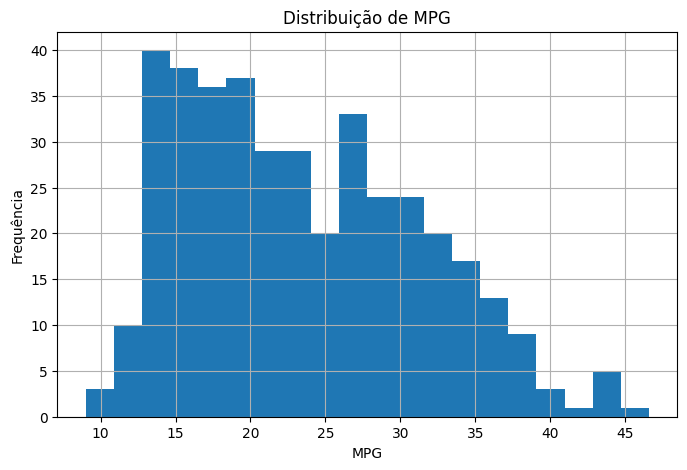

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(y_clean, bins=20)
plt.title("Distribuição de MPG")
plt.xlabel("MPG")
plt.ylabel("Frequência")
plt.grid(True)
plt.show()

### <font color='cyan'>Q3) O que a distribuição do histograma nos diz sobre o consumo de combustível da maioria dos carros desse dataset?</font>

A maioria dos carros está concentrada aproximadamente na faixa de 15 e 30 MPG, indicando que veículos com eficiência intermediária são predominantes no dataset. Além disso, a distribuição apresenta uma leve queda á direita, com alguns poucos veículos alcançando valores mais altos de MPG, o que sugere a presença de menos carros mais eficiência. Também há poucos veículos com consumo muito baixo, indicando que extremos são menos frequentes na base de dados.

## <font color='green'>**2. Regressão Linear, Polinomial e Visualização**</font>

### <font color='cyan'>Q4) Crie um gráfico de dispersão (scatter plot) de `weight` vs `mpg`.</font>

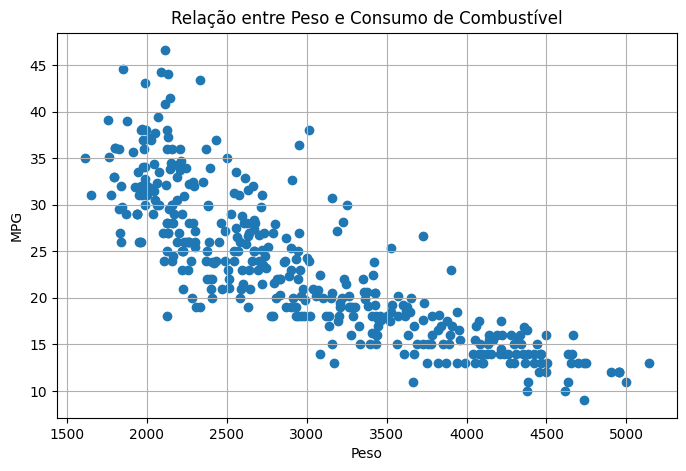

In [8]:
plt.figure(figsize=(8,5))
plt.scatter(X_clean['weight'], y_clean)

plt.title("Relação entre Peso e Consumo de Combustível")
plt.xlabel("Peso")
plt.ylabel("MPG")
plt.grid(True)
plt.show()

### <font color='cyan'>Q5) Observando o gráfico de dispersão gerado na questão anterior, como você descreveria a relação entre o peso do veículo (weight) e o consumo de combustível (mpg)? A relação parece ser estritamente linear ou apresenta um comportamento não linear? Justifique sua resposta.</font>

É possível observar uma relação negativa entre peso e consumo de combustível, ou seja, à medida que o peso aumenta os carros passam a ser menos eficientes no consumo de combustível. A curva possuí uma tendência aproximadamente linear mas em alguns pontos, proxímos  a pesos menores, há uma leve curvatura.

### <font color='cyan'>Q6) Divida o conjunto de dados em treinamento (80%) e teste (20%), utilizando a variável `weight` como entrada e `mpg` como alvo, e em seguida construa um gráfico de dispersão que apresente os dois subconjuntos com cores diferentes, incluindo título, rótulos dos eixos e uma legenda para identificar claramente os dados de treino e de teste.</font>

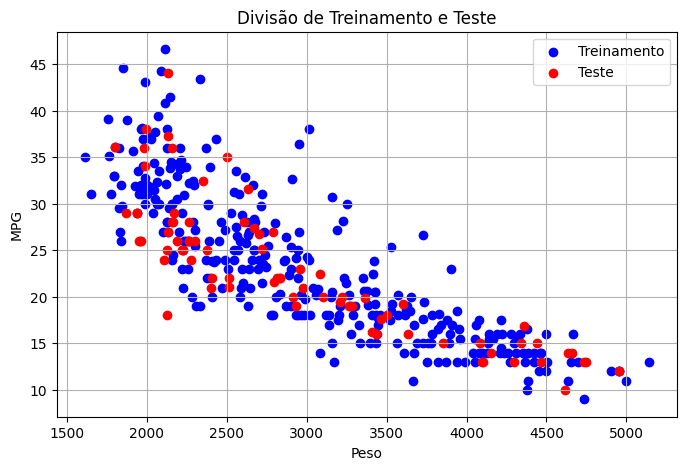

In [10]:
from sklearn.model_selection import train_test_split

#definir variável de entrada e saída
X_weight = X_clean['weight']

X_train, X_test, y_train, y_test = train_test_split(
    X_weight, y_clean, test_size=0.2, random_state=42
)

plt.figure(figsize=(8,5))

plt.scatter(X_train, y_train, label='Treinamento', color='blue')
plt.scatter(X_test, y_test, label='Teste', color='red')

plt.title("Divisão de Treinamento e Teste")
plt.xlabel("Peso")
plt.ylabel("MPG")
plt.legend()
plt.grid(True)
plt.show()

### <font color='cyan'>Q7) Com base na distribuição dos pontos no gráfico gerado, os conjuntos de treinamento e teste parecem ser representativos do conjunto de dados original? Justifique sua resposta observando a dispersão das cores.</font>

Observando o gráfico o conjunto de treinamento e o de teste parecem ser bem representativos dos conjuntos de dados original, ambos estão bem distribuídos ao longo de toda a faixa de valores de peso e MPG. Os pontos de teste não estão concentrados em uma região específica, mas sim espalhados de forma semelhante aos dados de treinamento, acompanhando a mesma tendência descrescente. Isso indica que a divisão foi realizada de froma adequada, preservando a variabilidade dos dados e garantindo que o modelo treinado tenha boa capacidade de generalização.

### <font color='green'>Antes de avaliarmos nosso modelo, vamos entender brevemente o que cada métrica significa e quais funções da biblioteca [`sklearn.metrics`](https://scikit-learn.org/stable/api/sklearn.metrics.html) utilizaremos:</font>
- #### <font color='green'>R² (Coeficiente de Determinação) - função `r2_score(y_true, y_pred)`: Mede o quão bem o modelo se ajusta aos dados. Ele indica a proporção da variabilidade da variável alvo (MPG) que é explicada pelo modelo. Varia geralmente de 0 a 1 (podendo ser negativo se o modelo for pior que uma linha média). Quanto mais próximo de 1, melhor.</font>
- #### <font color='green'>MAE (Erro Absoluto Médio - Mean Absolute Error) - função `mean_absolute_error(y_true, y_pred)`: Representa a média das diferenças em valor absoluto entre as previsões do modelo e os valores reais. É uma métrica muito intuitiva porque o erro é retornado na mesma unidade da variável alvo (ou seja, errar por "3 MPG"). Quanto menor, melhor.</font>
- #### <font color='green'>MSE (Erro Quadrático Médio - Mean Squared Error) - função `mean_squared_error(y_true, y_pred)`: Calcula a média dos erros elevados ao quadrado. Como os erros são elevados ao quadrado, o MSE penaliza erros maiores (outliers) de forma mais severa do que o MAE. Quanto menor, melhor.</font>

### <font color='cyan'>Q8) Importe as funções `r2_score`, `mean_absolute_error` e `mean_squared_error` do módulo `sklearn.metrics`. Em seguida, treine um modelo de Regressão Linear Simples para prever o MPG usando o peso. Faça as previsões para o conjunto de treinamento e para o conjunto de teste. Por fim, imprima as métricas (R², MAE e MSE) para ambos os conjuntos.</font>

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

#treina modelo linear
linear_model = LinearRegression()
linear_model.fit(X_train.values.reshape(-1, 1), y_train)

#previsão
y_train_pred_linear = linear_model.predict(X_train.values.reshape(-1, 1))
y_test_pred_linear = linear_model.predict(X_test.values.reshape(-1, 1))

######## MÉTRICAS #########
#treino

print("====== Regressão Linear: Treinamento ======")
print(f"R²: {r2_score(y_train, y_train_pred_linear)}")
print(f"MAE: {mean_absolute_error(y_train, y_train_pred_linear)}")
print(f"MSE: {mean_squared_error(y_train, y_train_pred_linear)}")

#teste

print("\n====== Regressão Linear: Teste ======")
print(f"R²: {r2_score(y_test, y_test_pred_linear)}")
print(f"MAE: {mean_absolute_error(y_test, y_test_pred_linear)}")
print(f"MSE: {mean_squared_error(y_test, y_test_pred_linear)}")



====== Regressão Linear: Treinamento ======
R²: 0.6981745885310532
MAE: 3.2855106233763385
MSE: 19.04510619658238

====== Regressão Linear: Teste ======
R²: 0.6533466675646016
MAE: 3.4641211922147592
MSE: 17.693388269545686


### <font color='cyan'>Q9) Compare os erros (MAE e MSE) obtidos no conjunto de treinamento com os erros do conjunto de teste. Com base nessa comparação e no conceito de viés/variância, o modelo parece estar sofrendo de subajuste (underfitting), sobreajuste (overfitting) ou apresenta um bom ajuste? Justifique.</font>

O modelo não apresenta sinais de overfitting, pois o desempreno do teste não é significativamente pior que no treino. No entanto como R² não é extremamente alto sabemos que a relação entre peso e MPG não é perfeitamente linear, há indícios  de um leve subajuste, já que o mmodelo linear pode não capturar totalmente a complexidade dos dados. De maneira geral o modelo possuí um bom ajuste.

### <font color='cyan'>Q10) Treine um modelo de Regressão Polinomial (grau 2) para prever o MPG usando o peso. em seguida, Assim como na questão anterior, faça previsões e imprima as métricas (R², MAE e MSE) para os conjuntos de treinamento e de teste.</font>
- #### <font color='cyan'>Dica: Como as características polinomiais elevam os valores ao quadrado, a escala dos dados muda drasticamente. Utilize a classe `Pipeline` do Scikit-Learn para encadear a criação de `PolynomialFeatures(degree=2)`, a normalização com StandardScaler e o modelo LinearRegression.<font>

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# pipeline para regressão polinomial grau 2
poly2_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("scaler", StandardScaler()),
    ("linear", LinearRegression())
])

# treinar
poly2_model.fit(X_train.values.reshape(-1, 1), y_train)

# previsões
y_train_pred_poly2 = poly2_model.predict(X_train.values.reshape(-1, 1))
y_test_pred_poly2 = poly2_model.predict(X_test.values.reshape(-1, 1))

# métricas - treino
print("=== Regressão Polinomial Grau 2: Treinamento ===")
print("R²:", r2_score(y_train, y_train_pred_poly2))
print("MAE:", mean_absolute_error(y_train, y_train_pred_poly2))
print("MSE:", mean_squared_error(y_train, y_train_pred_poly2))

# métricas - teste
print("\n=== Regressão Polinomial Grau 2: Teste ===")
print("R²:", r2_score(y_test, y_test_pred_poly2))
print("MAE:", mean_absolute_error(y_test, y_test_pred_poly2))
print("MSE:", mean_squared_error(y_test, y_test_pred_poly2))

=== Regressão Polinomial Grau 2: Treinamento ===
R²: 0.72134647941912
MAE: 3.079780589881891
MSE: 17.582965813534294

=== Regressão Polinomial Grau 2: Teste ===
R²: 0.6730234425893193
MAE: 3.1383262829057914
MSE: 16.689074196004476


### <font color='cyan'>Q11) Avaliando os erros de treinamento e teste deste modelo polinomial (grau 2), como ele se compara ao modelo linear da questão anterior? Ele apresenta sinais de underfitting, overfitting ou um bom ajuste aos dados? Justifique.</font>

Comparando o modelo polinomial de grau 2 com o modelo de regressão linear, observa-se que o modelo polinomial apresentou melhor desempenho em ambos os conjuntos. O valor de R² aumentou de aproximadamente 0,70 para 0,72 no treinamento e de 0,65 para 0,67 no teste, indicando maior capacidade de explicar a variabilidade dos dados. Além disso, os erros MAE e MSE diminuíram tanto no treino quanto no teste, o que mostra que as previsões do modelo polinomial estão mais próximas dos valores reais.

Outro ponto importante é que os valores das métricas entre treinamento e teste permanecem bastante próximos (por exemplo, MAE de 3,08 no treino e 3,13 no teste), o que indica que o modelo não apresenta sinais de overfitting. Dessa forma, o modelo polinomial de grau 2 apresenta um bom ajuste aos dados, pois consegue capturar melhor a relação não linear entre peso e consumo sem comprometer a capacidade de generalização.

### <font color='cyan'>Q12) Utilizando os modelos já treinados, construa um gráfico de dispersão com os dados reais de treinamento e teste (`weight` vs `mpg`), diferenciando-os por cores, e sobreponha, no mesmo gráfico, as curvas de predição dos modelos de Regressão Linear Simples e Regressão Polinomial (grau 2), incluindo título, rótulos dos eixos e legenda para identificar os subconjuntos e cada regressão.</font>

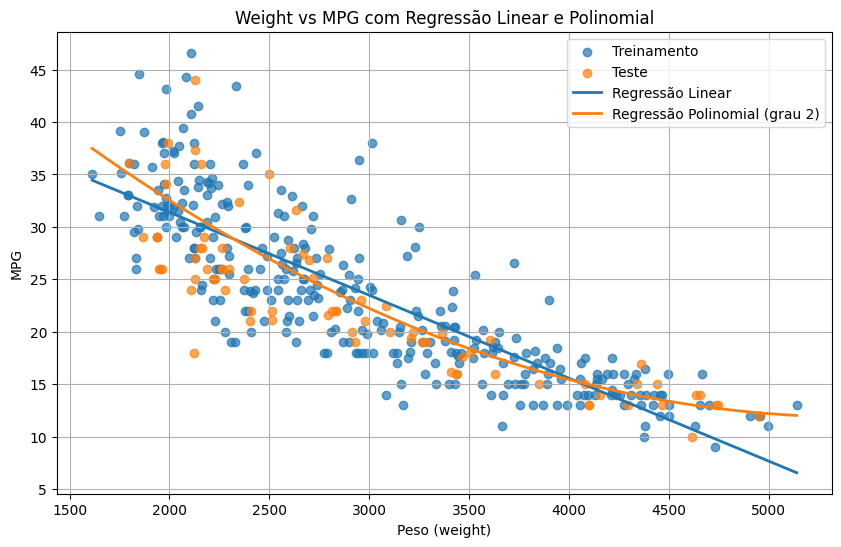

In [15]:
import numpy as np

# Criar uma sequência ordenada de pesos para desenhar as curvas
X_range = np.linspace(X_weight.min(), X_weight.max(), 500).reshape(-1, 1)

# Previsões das curvas
y_range_linear = linear_model.predict(X_range)
y_range_poly2 = poly2_model.predict(X_range)

# Gráfico
plt.figure(figsize=(10,6))

plt.scatter(X_train, y_train, label="Treinamento", alpha=0.7)
plt.scatter(X_test, y_test, label="Teste", alpha=0.7)

plt.plot(X_range, y_range_linear, label="Regressão Linear", linewidth=2)
plt.plot(X_range, y_range_poly2, label="Regressão Polinomial (grau 2)", linewidth=2)

plt.title("Weight vs MPG com Regressão Linear e Polinomial")
plt.xlabel("Peso (weight)")
plt.ylabel("MPG")
plt.legend()
plt.grid(True)

plt.show()

### <font color='cyan'>Q13) Com base no gráfico gerado, qual modelo parece se ajustar melhor aos dados? A relação entre `weight` e `mpg` parece ser linear ou não linear? Explique.</font>

Com base no gráfico, o modelo de regressão polinomial de grau 2 parece se ajustar melhor aos dados, pois sua curva acompanha mais fielmente a distribuição dos pontos ao longo de toda a faixa de valores. Enquanto a regressão linear representa apenas uma tendência reta, o modelo polinomial consegue capturar a curvatura presente na relação entre peso e MPG, especialmente nas extremidades do gráfico.

Dessa forma, observa-se que a relação entre weight e mpg não é estritamente linear, mas sim levemente não linear, o que justifica o melhor desempenho do modelo polinomial.

### <font color='cyan'>Q14) Os resultados observados no gráfico são consistentes com a análise das métricas? Explique possíveis diferenças entre a avaliação quantitativa (métricas) e a avaliação visual do ajuste dos modelos.</font>

Sim, os resultados observados no gráfico são consistentes com a análise das métricas. O modelo polinomial apresentou melhores valores de R² e menores erros (MAE e MSE) em comparação ao modelo linear, o que indica um melhor desempenho quantitativo. Visualmente, isso também é confirmado, já que a curva polinomial acompanha melhor a distribuição dos pontos, enquanto a reta linear se distancia mais dos dados em algumas regiões.

### <font color='cyan'>Q15) Para observar o efeito do sobreajuste (overfitting) na prática, treine um novo modelo de Regressão Polinomial, mas desta vez utilizando um grau bem alto (por exemplo, grau 15 ou 20). Utilize o mesmo processo com o Pipeline (incluindo o escalonamento). Imprima as métricas de treinamento e teste. O que acontece com o desempenho no conjunto de teste em comparação ao de treinamento? Explique o fenômeno ocorrido.</font>

In [18]:

poly_high_model = Pipeline([
    ("poly", PolynomialFeatures(degree=15)),
    ("scaler", StandardScaler()),
    ("linear", LinearRegression())
])

poly_high_model.fit(X_train.values.reshape(-1,1), y_train)

y_train_pred_high = poly_high_model.predict(X_train.values.reshape(-1,1))
y_test_pred_high = poly_high_model.predict(X_test.values.reshape(-1,1))

# métricas - treino
print("=== Regressão Polinomial Grau 15: Treinamento ===")
print("R²:", r2_score(y_train, y_train_pred_high))
print("MAE:", mean_absolute_error(y_train, y_train_pred_high))
print("MSE:", mean_squared_error(y_train, y_train_pred_high))

# métricas - teste
print("\n=== Regressão Polinomial Grau 15: Teste ===")
print("R²:", r2_score(y_test, y_test_pred_high))
print("MAE:", mean_absolute_error(y_test, y_test_pred_high))
print("MSE:", mean_squared_error(y_test, y_test_pred_high))

=== Regressão Polinomial Grau 15: Treinamento ===
R²: 0.7327703085197614
MAE: 3.038874336983417
MSE: 16.86212512177661

=== Regressão Polinomial Grau 15: Teste ===
R²: 0.6607155225334981
MAE: 3.1583075349946808
MSE: 17.31727761412323


Ao utilizar um modelo polinomial de grau elevado (grau 15), observa-se que o desempenho no conjunto de treinamento melhora em relação aos modelos anteriores, com aumento do R² para aproximadamente 0,73 e redução dos erros (MAE e MSE). No entanto, no conjunto de teste, o desempenho não melhora na mesma proporção: o R² é menor (cerca de 0,66) e os erros são ligeiramente maiores em comparação ao treinamento.

Esse comportamento indica que o modelo está se ajustando excessivamente aos dados de treinamento, capturando não apenas a tendência geral, mas também ruídos e variações específicas desse conjunto. Como consequência, o modelo perde capacidade de generalização para novos dados ou seja overfitting (sobreajuste).

## <font color='green'>**3. Otimização com Gradiente Descendente**</font>

### <font color='cyan'>Q16) Tente treinar um `SGDRegressor` diretamente nos dados originais de `X` (removendo valores nulos se houver) e observe o erro.</font>

In [19]:
from sklearn.linear_model import SGDRegressor

# Usar os dados sem normalização
X_weight = X_clean[["weight"]]

# Divisão
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_weight, y_clean, test_size=0.2, random_state=42
)

# Modelo SGD
sgd = SGDRegressor(random_state=42, max_iter=1000)

# Treinar
sgd.fit(X_train, y_train)

# Previsões
y_train_pred_sgd = sgd.predict(X_train)
y_test_pred_sgd = sgd.predict(X_test)

# Métricas
print("=== SGD sem normalização ===")
print("R² treino:", r2_score(y_train, y_train_pred_sgd))
print("R² teste:", r2_score(y_test, y_test_pred_sgd))
print("MAE teste:", mean_absolute_error(y_test, y_test_pred_sgd))
print("MSE teste:", mean_squared_error(y_test, y_test_pred_sgd))

=== SGD sem normalização ===
R² treino: -1.721884785033037e+29
R² teste: -2.0886023060684893e+29
MAE teste: 3128088472607351.0
MSE teste: 1.0660347985786357e+31


### <font color='cyan'>Q17) Agora, aplique o `StandardScaler` do Scikit-Learn nos dados e treine o `SGDRegressor` novamente.</font>

In [20]:
sgd_scaled = Pipeline([
    ("scaler", StandardScaler()),
    ("sgd", SGDRegressor(random_state=42, max_iter=1000))
])

# Treinar
sgd_scaled.fit(X_train, y_train)

# Previsões
y_train_pred_sgd_scaled = sgd_scaled.predict(X_train)
y_test_pred_sgd_scaled = sgd_scaled.predict(X_test)

# Métricas
print("=== SGD com normalização ===")
print("R² treino:", r2_score(y_train, y_train_pred_sgd_scaled))
print("R² teste:", r2_score(y_test, y_test_pred_sgd_scaled))
print("MAE teste:", mean_absolute_error(y_test, y_test_pred_sgd_scaled))
print("MSE teste:", mean_squared_error(y_test, y_test_pred_sgd_scaled))

=== SGD com normalização ===
R² treino: 0.6981622846131954
R² teste: 0.6550200418365147
MAE teste: 3.451716349432937
MSE teste: 17.607978270728655


### <font color='cyan'>Q18) Compare os resultados das duas abordagens e explique por que a normalização é importante para algoritmos baseados em gradiente descendente. Relacione sua resposta com o comportamento do gradiente e a escala das variáveis.</font>

Comparando os resultados, observa-se uma diferença extremamente significativa entre as duas abordagens. Sem normalização, o modelo SGD apresentou valores completamente instáveis, com R² extremamente negativo e erros (MAE e MSE) muito elevados, indicando que o modelo não conseguiu aprender adequadamente a relação entre as variáveis. Já com a aplicação do StandardScaler, o modelo apresentou desempenho muito melhor, com R² em torno de 0,65 no conjunto de teste e erros bem menores, semelhantes aos obtidos com regressão linear tradicional.
Essa diferença ocorre porque algoritmos baseados em gradiente descendente são altamente sensíveis à escala das variáveis. Quando os dados não estão normalizados, atributos com valores muito grandes, como o peso dos veículos, dominam o cálculo do gradiente, fazendo com que as atualizações dos parâmetros sejam desproporcionais e instáveis. Isso pode levar a oscilações, divergência do modelo ou dificuldade de convergência.

## <font color='green'>**4. Validação Cruzada e Regularização (LASSO)**</font>

### <font color='green'>A Regressão LASSO (Least Absolute Shrinkage and Selection Operator) é uma evolução da Regressão Linear tradicional. Na regressão comum, o modelo foca apenas em reduzir o erro. O problema é que, ao tentar usar todas as variáveis disponíveis, ele pode acabar decorando ruídos e gerando overfitting. O LASSO resolve isso adicionando uma penalidade aos coeficientes (pesos) das variáveis.</font>
- #### <font color='green'>O grande diferencial da regularização do LASSO (chamada de L1) é que ela consegue forçar os coeficientes de variáveis inúteis ou redundantes a se tornarem exatamente zero. Ou seja, o próprio modelo decide quais dados ignorar, entregando uma equação final mais simples, limpa e interpretável.</font>
- #### <font color='green'>O hiperparâmetro `alpha` é o "botão de volume" da penalidade. Se alpha = 0, temos uma regressão linear normal. Quanto maior o valor de alpha, mais severa é a penalização e mais atributos o modelo irá descartar.</font>

### <font color='green'>Caso queira entender a matemática por trás da função de custo, consulte os seguintes materiais:</font>
- #### <font color='green'>Anexo III do [material  teórico](https://github.com/zz4fap/c24_inteligencia_artificial/blob/main/slides/C24_Regress%C3%A3o.pdf) da disciplina  (slides 96 em diante);</font>
- #### <font color='green'>Documentação oficial do Scikit-Learn sobre [modelos lineares com LASSO](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html);</font>
- #### <font color='green'>Vídeo ["Regularization Part 2: Lasso (L1) Regression"](https://www.youtube.com/watch?v=NGf0voTMlcs), do canal "StatQuest with Josh Starmer", com uma explicação didática e visual sobre como a matemática do LASSO zera os coeficientes.</font>

### <font color='cyan'>Q19) O algoritmo LASSO é extremamente sensível à escala dos dados, pois ele penaliza a magnitude bruta dos coeficientes. Crie um `Pipeline` que aplique o `StandardScaler` e, em seguida, o modelo `Lasso(alpha=1.0)`. Treine-o com todos os dados (`X` e `y`) e exiba os coeficientes finais. A aplicação da normalização mudou a relevância que o modelo deu às variáveis em comparação com a Q16 (onde não usamos normalização)? Explique.</font>

In [21]:
from sklearn.linear_model import Lasso
import pandas as pd

# Usar todas as variáveis do dataset limpo
X_all = X_clean.copy()

# Criar pipeline
lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=1.0, random_state=42, max_iter=10000))
])

# Treinar com todos os dados
lasso_model.fit(X_all, y_clean)

# Obter coeficientes
coeficientes = lasso_model.named_steps["lasso"].coef_

# Criar tabela com nome das variáveis e coeficientes
coef_df = pd.DataFrame({
    "Variável": X_all.columns,
    "Coeficiente": coeficientes
})

print(coef_df)

       Variável  Coeficiente
0     cylinders    -0.000000
1  displacement    -0.000000
2    horsepower    -0.167737
3        weight    -4.545500
4  acceleration     0.000000
5    model_year     1.994430
6        origin     0.308293


A aplicação da normalização mudou a relevância atribuída pelo modelo às variáveis. Isso ocorre porque o LASSO penaliza diretamente a magnitude dos coeficientes, e essa magnitude depende da escala das variáveis. Sem normalização, variáveis com valores maiores, como weight, podem dominar o modelo não necessariamente por serem mais importantes, mas por possuírem maior escala numérica.

Com a aplicação do StandardScaler, todas as variáveis passam a ter média zero e desvio padrão igual a um, ficando na mesma escala. Isso permite que o LASSO compare as variáveis de forma mais justa, aplicando a penalização de maneira equilibrada. Como resultado, o modelo consegue identificar com mais precisão quais variáveis são realmente relevantes, zerando os coeficientes das menos importantes e mantendo apenas aquelas que contribuem significativamente para a predição.


### <font color='cyan'>Q20) O hiperparâmetro alpha é quem dita a força da regularização. Utilizando o mesmo processo com o Pipeline e o StandardScaler, treine três modelos LASSO distintos, alterando o valor de alpha para: 0.1, 1.0 e 5.0. Imprima apenas os nomes das variáveis que "sobreviveram" (ou seja, que tiveram coeficientes diferentes de zero) em cada modelo. O que acontece com a complexidade do modelo à medida que o valor de alpha aumenta?</font>

In [22]:
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

alphas = [0.1, 1.0, 5.0]

for alpha in alphas:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", Lasso(alpha=alpha, random_state=42, max_iter=10000))
    ])

    model.fit(X_all, y_clean)

    coefs = model.named_steps["lasso"].coef_
    survived = X_all.columns[coefs != 0]

    print(f"\nAlpha = {alpha}")
    print("Variáveis que sobreviveram:")
    for var in survived:
        print("-", var)


Alpha = 0.1
Variáveis que sobreviveram:
- horsepower
- weight
- acceleration
- model_year
- origin

Alpha = 1.0
Variáveis que sobreviveram:
- horsepower
- weight
- model_year
- origin

Alpha = 5.0
Variáveis que sobreviveram:
- weight


Conforme o valor de alpha aumenta, a complexidade do modelo diminui, tornando-o mais simples e interpretável. No entanto, um valor muito alto pode simplificar excessivamente o modelo, levando à perda de informações importantes e possível redução no desempenho preditivo.